# Passive error correction of photon loss (PReSPA): Hamiltonian review

**Paper.** S. Shirol, S. van Geldern, H. Xi & C. Wang, "Passive Quantum Error Correction of Photon Loss at
Breakeven", *Phys. Rev. X* **16**, 021042 (2026). Local copy:
`sources/Passive Quantum Error Correction of Photon Loss at Breakeven.pdf`. All equation, table, figure and
appendix numbers below refer to this PRX version.

**What the paper does.** A logical qubit is stored in a microwave cavity, using a code whose states contain
only odd photon numbers. When the cavity loses a photon, the photon number becomes even. Two sets ("combs")
of weak, always-on microwave tones then add a photon back, but only when the photon number is even. The
entropy of the error leaves through a lossy readout resonator. There is no measurement and no feedback. The
scheme is called PReSPA: **p**arity **re**covery by **s**elective **p**hoton **a**ddition.

**What this notebook is.** A reconstruction of the Hamiltonian, the drives and the dissipation, ending with the
master equation we propose to simulate (§8). §10 simulates it and reproduces all four panels of PRX Fig. 2.
The last cell recomputes every derived number from `AQEC/device.py`.

This is a third device, separate from the cat-code chip in `core/grape_core.py` and the EsT chip in
`EST/device.py`. Every parameter comes from PRX Table I and is stored in `AQEC/device.py`.

## For the reviewer: what needs approval

| # | item | what we propose | where |
|:-:|---|---|:-:|
| 1 | Device parameters | PRX Table I, unchanged | [§2](#2-device-parameters) |
| 2 | System Hamiltonian $\hat H_0$ | PRX Eq. (2): three modes, dispersive couplings only | [§3](#3-system-hamiltonian) |
| 3 | Drive Hamiltonian $\hat H_d$ | PRX Eq. (3): one resonant tone per correction path, with the paper's fitted rates $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz | [§6](#6-drive-hamiltonian-from-the-lab-to-prx-eq-3) |
| 4 | Dissipation | storage loss, readout loss, and two separate transmon decays ($f \to e$ and $e \to g$) | [§8.1](#81-master-equation-and-jump-operators) |
| 5 | Truncation, initial states, benchmark | see the model summary | [§8](#8-the-model-we-propose-to-simulate) |

**Open decisions.** Each one is explained where it comes up, and both are collected in [§8.5](#85-decisions-for-the-reviewer).

- **D1.** Keep the storage self-Kerr $K$ and the sixth-order shift $\chi'_q$ in $\hat H_0$? The paper drops them,
  but they shift the $n = 5$ correction path by an amount comparable to $\Omega_1$ ([§3.2](#32-terms-the-paper-leaves-out-and-decision-d1)).
- **D3.** Include thermal excitation, drive-induced heating and dephasing from the start, or add them in a
  second pass ([§8.1](#81-master-equation-and-jump-operators))?

## Contents

1. [The idea in one page](#1-the-idea-in-one-page)
2. [Device parameters](#2-device-parameters)
3. [System Hamiltonian](#3-system-hamiltonian)
4. [The code: odd-parity binomial code with mean photon number 3](#4-the-code-odd-parity-binomial-code-with-mean-photon-number-3)
5. [The six drive tones](#5-the-six-drive-tones)
6. [Drive Hamiltonian: from the lab to PRX Eq. (3)](#6-drive-hamiltonian-from-the-lab-to-prx-eq-3)
7. [Dissipation and the choice of drive rates](#7-dissipation-and-the-choice-of-drive-rates)
8. [The model we propose to simulate](#8-the-model-we-propose-to-simulate)
9. [Error budget of the experiment](#9-error-budget-of-the-experiment-prx-table-iii)
10. [Simulating PReSPA: PRX Fig. 2](#10-simulating-prespa-prx-fig-2)

- [Appendix A. Experimental setup](#appendix-a-experimental-setup-app-a1-a2-fig-7)
- [Appendix B. Numerical check of every derived number](#appendix-b-numerical-check-of-every-derived-number)

# 1. The idea in one page

**Three modes** (PRX Fig. 1b).

| mode | operator | role |
|---|:-:|---|
| storage cavity | $\hat a$ | holds the logical qubit; long-lived ($T_{1a} = 136$ μs) |
| transmon | $\hat q$ | nonlinear helper ("ancilla"); its levels $\lvert g\rangle, \lvert e\rangle, \lvert f\rangle$ are all used |
| readout resonator | $\hat r$ | short-lived ($1/\kappa_r \approx 0.27$ μs); acts as a cold "reservoir" that carries entropy away |

A product state is written $|n, j, m\rangle$: $n$ storage photons, transmon level $j \in \{g, e, f\}$, and $m$
readout photons.

**The code** (PRX Eq. 1). The logical states contain only odd photon numbers:
$|0_L\rangle = (|1\rangle + |5\rangle)/\sqrt2$ and $|1_L\rangle = |3\rangle$. Losing one photon makes the photon
number even. The parity of the photon number (odd or even) therefore shows whether an error happened, without
revealing the logical state.

**One correction cycle** (PRX Fig. 1c: red arrows are comb 1, blue arrows comb 2, green is the readout decay).
For each path $n \in \{1, 3, 5\}$:

| step | transition | caused by | rate |
|:-:|---|---|---|
| error | $\lvert n, g, 0\rangle \to \lvert n{-}1, g, 0\rangle$ | a photon leaks out of the storage | $\kappa_a$ per photon; $\bar n\kappa_a \approx (45\ \mu\text{s})^{-1}$ for the code |
| 1 | $\lvert n{-}1, g, 0\rangle \to \lvert n, f, 0\rangle$ | comb-1 tone at $\omega_{d1,n}$ adds a storage photon **and** lifts the transmon from $g$ to $f$ | $\Omega_1$ |
| 2 | $\lvert n, f, 0\rangle \to \lvert n, g, 1\rangle$ | comb-2 tone at $\omega_{d2,n}$ returns the transmon to $g$ and puts one photon in the readout | $\Omega_2$ |
| 3 | $\lvert n, g, 1\rangle \to \lvert n, g, 0\rangle$ | the readout photon leaks out of the device | $\kappa_r$ |

Net effect of steps 1–3: $|n{-}1, g, 0\rangle \to |n, g, 0\rangle$. The lost photon is replaced, and the transmon
and readout are back in their ground states, ready for the next error.

**Why only even photon numbers are corrected.** The transmon's $g \to f$ frequency depends on the storage photon
number: it drops by $\chi_{gf}$ per photon, with $\chi_{gf}/2\pi = 2.07$ MHz. Each comb-1 tone is tuned to one
even photon number (0, 2 or 4). Odd photon numbers sit at least $\chi_{gf}$ away from every tone, and the tones
are weak ($\Omega_1 \ll \chi_{gf}$), so the code states are left almost untouched.

**Why the correction keeps superpositions.** The error state $\propto |0\rangle + \sqrt5\,|4\rangle$ must be
corrected along two paths at once ($0 \to 1$ and $4 \to 5$). If the photon leaving the readout revealed which path
was taken, the superposition would collapse. The tones are chosen so that every path emits an identical photon,
with the same frequency and the same time profile ([§5.3](#53-the-sum-rule-why-the-correction-keeps-superpositions)).

**Rate hierarchy** (each value is the angular rate divided by $2\pi$):

$$
\underbrace{\kappa_a}_{1.2\ \text{kHz}}
\;\ll\; \underbrace{\Omega_1}_{55\ \text{kHz}}
\;<\; \underbrace{\Omega_2}_{160\ \text{kHz}}
\;\sim\; \underbrace{\kappa_r/4}_{145\ \text{kHz}}
\;\ll\; \underbrace{\chi_{gf}}_{2.07\ \text{MHz}}
$$

The left inequality makes correction fast compared with errors. The right inequality makes it selective. The
middle is deliberate: $\Omega_2$ and $\kappa_r$ are comparable, not widely separated, because that gives the
fastest correction ([§7.2](#72-critical-damping-the-fastest-correction)).

# 2. Device parameters

**Units.** Frequencies are quoted as $\omega/2\pi$ in MHz or kHz, as in the paper. Inside equations every
$\omega$, $\alpha$, $\chi$, $K$, $\Omega$ and $\kappa$ is an angular frequency (rad/μs). `AQEC/device.py` stores them
that way (lab value × $2\pi$). A decay rate is $\kappa = 1/T_1$.

**Signs.** The paper writes every nonlinear term with an explicit minus sign and a **positive** coefficient, for
example $-\chi_{ge}|e\rangle\langle e|\hat a^\dagger\hat a$ with $\chi_{ge} > 0$. `AQEC/device.py` follows the paper.
`EST/device.py` uses the opposite convention (signed coefficients with a plus sign), so values must not be copied
between the two files without flipping signs.

**Table 1.** Hamiltonian parameters (PRX Table I). The last column names the term each parameter multiplies in
$\hat H_0$ ([§3](#3-system-hamiltonian)).

| quantity | symbol | value | term |
|---|:-:|:-:|:-:|
| **Mode frequencies** | | | |
| transmon $g \to e$ frequency | $\omega_q/2\pi$ | 3482.9 MHz | $\omega_q\,\hat q^\dagger\hat q$ |
| storage frequency | $\omega_a/2\pi$ | 4657.9 MHz | $\omega_a\,\hat a^\dagger\hat a$ |
| readout frequency | $\omega_r/2\pi$ | 8725 MHz | $\omega_r\,\hat r^\dagger\hat r$ |
| **Nonlinearities** | | | |
| transmon anharmonicity | $\alpha_q/2\pi$ | 134.28 MHz | $-\tfrac{\alpha_q}{2}\,\hat q^{\dagger2}\hat q^{2}$ |
| storage self-Kerr | $K/2\pi$ | 3.3 kHz | $-\tfrac{K}{2}\,\hat a^{\dagger2}\hat a^{2}$ (not in Eq. 2) |
| sixth-order storage–transmon shift | $\chi'_q/2\pi$ | 1.9 kHz | $+\tfrac{\chi'_q}{2}\,\hat q^\dagger\hat q\,\hat a^{\dagger2}\hat a^{2}$ (not in Eq. 2) |
| **Dispersive couplings** | | | |
| storage shift per transmon in $\lvert e\rangle$ | $\chi_{ge}/2\pi$ | 1.12 MHz | $-\chi_{ge}\,\lvert e\rangle\langle e\rvert\,\hat a^\dagger\hat a$ |
| extra storage shift going $\lvert e\rangle \to \lvert f\rangle$ | $\chi_{ef}/2\pi$ | 0.95 MHz | enters only through $\chi_{gf}$ |
| readout shift per transmon in $\lvert e\rangle$ | $\chi_{qr}/2\pi$ (Table I: $\chi_r$) | 1.13 MHz | $-\chi_{qr}\,\lvert e\rangle\langle e\rvert\,\hat r^\dagger\hat r$ |
| **Readout loss** | | | |
| readout decay rate | $\kappa_r/2\pi$ | 0.58 MHz | $\kappa_r\,\mathcal D[\hat r]$ |
| **Derived (computed, not measured)** | | | |
| storage shift per transmon in $\lvert f\rangle$ | $\chi_{gf} = \chi_{ge} + \chi_{ef}$ | 2.07 MHz | $-\chi_{gf}\,\lvert f\rangle\langle f\rvert\,\hat a^\dagger\hat a$ |
| transmon $g \to f$ frequency | $\omega_{gf} = 2\omega_q - \alpha_q$ | 6831.52 MHz | — |
| storage photon-loss rate | $\kappa_a = 1/T_{1a}$ | $\kappa_a/2\pi = 1.17$ kHz | $\kappa_a\,\mathcal D[\hat a]$ |

*Note.* App. A.1 quotes $\chi_{ge}/2\pi = 1.15$ MHz, while Table I and the main text give 1.12 MHz. We use 1.12 MHz.

**Table 2.** Coherence times and thermal populations (PRX Table I).

| quantity | symbol | value |
|---|:-:|:-:|
| **Transmon** | | |
| decay $\lvert e\rangle \to \lvert g\rangle$ | $T_1^{ge}$ | 50 μs |
| decay $\lvert f\rangle \to \lvert e\rangle$ | $T_1^{ef}$ | 31 μs |
| $g$–$e$ Ramsey coherence | $T_{2R}^{*}$ | 53 μs |
| $g$–$e$ echo coherence | $T_{2E}$ | 70 μs |
| $g$–$f$ Ramsey coherence | $T_{2,gf}^{*}$ | 30 μs |
| thermal $\lvert e\rangle$ population | $P_e^{\rm th}$ | 1.7% |
| **Storage cavity** | | |
| decay $\lvert 1\rangle \to \lvert 0\rangle$ | $T_{1a}$ | 136 μs |
| coherence | $T_{2a}$ | 235 μs |
| thermal $\lvert 1\rangle$ population | $P_1^{\rm th}$ | 0.6% |

# 3. System Hamiltonian

## 3.1 PRX Eq. (2)

$$
\frac{\hat H_0}{\hbar} = \omega_a \hat a^\dagger\hat a + \omega_q \hat q^\dagger\hat q + \omega_r \hat r^\dagger\hat r
- \frac{\alpha_q}{2}\hat q^{\dagger 2}\hat q^{2}
- \chi_{ge}\,|e\rangle\langle e|\,\hat a^\dagger\hat a
- \chi_{gf}\,|f\rangle\langle f|\,\hat a^\dagger\hat a
- \chi_{qr}\,|e\rangle\langle e|\,\hat r^\dagger\hat r
$$

Term by term:

- The first three terms are the energies of the three modes on their own.
- $-\tfrac{\alpha_q}{2}\hat q^{\dagger2}\hat q^2$ is the transmon anharmonicity. It lowers $|f\rangle$ by $\alpha_q$, so the
  $g \to f$ transition sits at $\omega_{gf} = 2\omega_q - \alpha_q$ rather than $2\omega_q$.
- $-\chi_{ge}|e\rangle\langle e|\hat a^\dagger\hat a$ and $-\chi_{gf}|f\rangle\langle f|\hat a^\dagger\hat a$ are the
  dispersive shifts. Each storage photon lowers the energy of $|e\rangle$ by $\chi_{ge}$ and of $|f\rangle$ by
  $\chi_{gf}$. This is how the transmon "sees" the photon number.
- $-\chi_{qr}|e\rangle\langle e|\hat r^\dagger\hat r$ is the same effect between transmon and readout. It is what
  makes dispersive readout possible.

Every term is diagonal in the states $|n, j, m\rangle$, so the energies can be read off directly:

$$
\frac{E_{n,j,m}}{\hbar} = n\,\omega_a + \epsilon_j + m\,\omega_r - n\,\chi_j - m\,\chi_{qr}\,\delta_{je},
\qquad
(\epsilon_g, \epsilon_e, \epsilon_f) = (0,\ \omega_q,\ \omega_{gf}),
\qquad
(\chi_g, \chi_e, \chi_f) = (0,\ \chi_{ge},\ \chi_{gf}).
$$

Here $\delta_{je} = 1$ if $j = e$ and $0$ otherwise. Every tone frequency in [§5](#5-the-six-drive-tones) is a difference of two
of these energies.

## 3.2 Terms the paper leaves out, and decision D1

Eq. (2) keeps only the dominant fourth-order terms. The paper names the others in App. C, App. A.1 and the
Table I caption:

| term | size ($/2\pi$) | what it does here |
|---|:-:|---|
| storage self-Kerr $-\tfrac{K}{2}\hat a^{\dagger2}\hat a^2$ | 3.3 kHz | the storage frequency depends on its own photon number |
| sixth-order shift $+\tfrac{\chi'_q}{2}\hat q^\dagger\hat q\,\hat a^{\dagger2}\hat a^2$ | 1.9 kHz | the dispersive shift itself grows with photon number |
| storage–readout cross-Kerr $\chi_{ar}$ | ≈ 9.3 kHz | acts only while a readout photon is present (about $1/\kappa_r = 0.27$ μs per cycle) |
| readout shift with the transmon in $\lvert f\rangle$ | not given | not needed: in the correction cycle $\lvert f\rangle$ and a readout photon never coexist |

**The paper's position.** App. C says $K$ and $\chi'_q$ "do not affect the correction scheme significantly" for this
code. The Table I caption adds that $\chi'_q$ "becomes important at higher storage photon populations", and
App. A.3 says both terms contribute to the error budget.

**Our estimate (not in the paper).** Adding $K$ and $\chi'_q$ to $\hat H_0$ moves the resonance of each correction
path $n$ (see [§5.1](#51-resonance-conditions) for the resonance conditions):

- stage 1, $|n{-}1,g,0\rangle \to |n,f,0\rangle$, moves by $-K(n-1) + \chi'_q\,n(n-1)$;
- stage 2, $|n,f,0\rangle \to |n,g,1\rangle$, moves by $-\chi'_q\,n(n-1)$;
- the sum of the two moves by $-K(n-1)$. So only $K$ breaks the sum rule of [§5.3](#53-the-sum-rule-why-the-correction-keeps-superpositions).

This assumes that $\chi'_q$ scales with $\hat q^\dagger\hat q$, so $|f\rangle$ gets twice the $|e\rangle$ value; the
paper gives no separate value for $|f\rangle$. With the paper's signs:

| path $n$ | $-K(n-1)$ | $+\chi'_q\,n(n-1)$ | stage-1 shift | stage-2 shift |
|:-:|:-:|:-:|:-:|:-:|
| 1 | 0 | 0 | 0 | 0 |
| 3 | −6.6 kHz | +11.4 kHz | +4.8 kHz | −11.4 kHz |
| 5 | −13.2 kHz | +38.0 kHz | +24.8 kHz | −38.0 kHz |

For comparison, $\Omega_1/2\pi = 55$ kHz. The $n = 5$ shifts are therefore not small on the scale of the drive. Both
shifts vanish on the $n = 1$ path, which is the only one the paper used to calibrate the tone frequencies
([§5.4](#54-how-the-tones-are-generated-and-calibrated-app-a4)). The paper does not say whether the $n = 3$ and $n = 5$ tones were adjusted separately.

> **Decision D1.** Proposal: first simulate with Eq. (2) exactly as printed (the paper's own fit model). Then
> rerun with $K$ and $\chi'_q$ added, as a sensitivity check. Both terms are diagonal, so adding them changes neither
> the frame nor the drive terms. They only add the path-dependent detunings in the table above.

# 4. The code: odd-parity binomial code with mean photon number 3

PRX Eq. (1) gives the code words. The error words are what the code words become after one photon loss,
normalised: $|j_E\rangle = \hat a|j_L\rangle \,/\, \lVert \hat a|j_L\rangle \rVert$.

$$
|0_L\rangle = \frac{|1\rangle + |5\rangle}{\sqrt2},\qquad |1_L\rangle = |3\rangle,
\qquad\qquad
|0_E\rangle = \frac{|0\rangle + \sqrt5\,|4\rangle}{\sqrt6},\qquad |1_E\rangle = |2\rangle .
$$

The code words have odd photon number (parity $\hat\Pi = e^{i\pi\hat a^\dagger\hat a} = -1$). The error words have even
photon number ($\hat\Pi = +1$). A single loss is therefore flagged by the parity alone.

**Is single-photon loss correctable?** The Knill–Laflamme conditions for the error set $\{\hat I, \hat a\}$ reduce to
three checks:

1. Both code words have the same mean photon number, $\tfrac12(1 + 5) = 3$ and $3$. A loss is then equally likely
   from either code word, so it reveals nothing about the logical state.
2. $\langle 0_L|\hat a^\dagger\hat a|1_L\rangle = 0$, because the two code words share no Fock states.
3. $\langle i_L|\hat a|j_L\rangle = 0$, because $\hat a$ changes the parity.

`AQEC/odd_kitten.py` asserts all three when it builds the code basis.

**Why mean photon number 3** (PRX Sec. II). A larger $\bar n$ reduces the code-word distortion described below,
but the code loses photons faster, at rate $\bar n\kappa_a$. $\bar n = 3$ balances the two. The paper calls it a
binomial code.

**Why odd parity** (*our reasoning; the paper does not spell it out*). The correction can only *add* photons. A code
word with a $|0\rangle$ component would lose that component for good, because the vacuum has no photon to lose, so
after an error there is nothing to add a photon back to. For example, in the even code
$\{(|0\rangle + |4\rangle)/\sqrt2,\ |2\rangle\}$ one loss turns $|0_L\rangle$ into $|3\rangle$, and adding a photon gives
$|4\rangle$, not $|0_L\rangle$. The odd code has no $|0\rangle$ component, so every Fock component survives a loss.

**The correction is approximate.** PReSPA adds one photon to every even Fock state at the same rate (the rates are
equalised on purpose, [§5.2](#52-the-numbers)). Its action is described by the jump operator (PRX Sec. II)

$$
\hat\Pi_{\rm cor} = \sqrt{\kappa_{\rm cor}}\,\sum_{n} |2n{+}1\rangle\langle 2n| ,
$$

which is not $\hat a^\dagger$: it has no $\sqrt n$ factors. Applied to the error word it gives

$$
\hat\Pi_{\rm cor}|0_E\rangle \;\propto\; \frac{|1\rangle + \sqrt5\,|5\rangle}{\sqrt6} \;\neq\; |0_L\rangle ,
$$

which has too much weight on $|5\rangle$. Stretches of time *without* a photon loss push the other way, because
$|5\rangle$ decays faster than $|1\rangle$. The two effects balance only on average. The random remainder is a slow
logical dephasing, about 0.5% per correction time $\tau_{\rm cor}$ (App. E.4). Removing it would need an engineered
four-photon dissipation (PRX Sec. II).

# 5. The six drive tones

## 5.1 Resonance conditions

A tone drives a transition when its frequency equals the energy difference ([§3.1](#31-prx-eq-2)). For correction path
$n \in \{1, 3, 5\}$:

**Stage 1**, $|n{-}1,g,0\rangle \to |n,f,0\rangle$ (comb 1):

$$
\omega_{d1,n} = \frac{E_{n,f,0}-E_{n-1,g,0}}{\hbar} = \omega_a + \omega_{gf} - n\,\chi_{gf} .
$$

**Stage 2**, $|n,f,0\rangle \to |n,g,1\rangle$ (comb 2):

$$
\omega_{d2,n} = \frac{E_{n,g,1}-E_{n,f,0}}{\hbar} = \omega_r - \omega_{gf} + n\,\chi_{gf} .
$$

These are the paper's formulas (Sec. II and App. A.3), $\omega_{d1} = \omega_a + (2\omega_q - \alpha_q - n\chi_{gf})$ and
$\omega_{d2} = \omega_r - (2\omega_q - \alpha_q - n\chi_{gf})$. In stage 1 one comb-1 photon becomes one storage photon
plus two transmon excitations. In stage 2 one comb-2 photon plus two transmon excitations become one readout photon.

## 5.2 The numbers

Each comb is built around a centre frequency (the local oscillator): $\bar\omega_{d1} = \omega_a + \omega_{gf}$ and
$\bar\omega_{d2} = \omega_r - \omega_{gf}$. Tone $n$ sits $n\chi_{gf}$ below (comb 1) or above (comb 2) the centre.

**Table 3.** The six tones, from Table 1 ($\omega_{gf}/2\pi = 6831.52$ MHz, $\chi_{gf}/2\pi = 2.07$ MHz).

| path $n$ | storage step | comb 1, $\omega_{d1,n}/2\pi$ (MHz) | comb-1 amplitude | comb 2, $\omega_{d2,n}/2\pi$ (MHz) | comb-2 amplitude | sum (MHz) |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| centre | — | 11489.42 | — | 1893.48 | — | 13382.90 |
| 1 | $\lvert 0\rangle \to \lvert 1\rangle$ | 11487.35 | $1$ | 1895.55 | 1 | 13382.90 |
| 3 | $\lvert 2\rangle \to \lvert 3\rangle$ | 11483.21 | $1/\sqrt3$ | 1899.69 | 1 | 13382.90 |
| 5 | $\lvert 4\rangle \to \lvert 5\rangle$ | 11479.07 | $1/\sqrt5$ | 1903.83 | 1 | 13382.90 |

Adjacent tones in a comb are $2\chi_{gf}/2\pi = 4.14$ MHz apart. The values match the paper's 11.49 GHz and 1.89 GHz
(App. A.3).

**Amplitudes** (App. A.4). Adding a photon to $|n{-}1\rangle$ comes with the factor $\langle n|\hat a^\dagger|n{-}1\rangle =
\sqrt n$. The comb-1 amplitudes are scaled by $1/\sqrt n$ to cancel it, so all three paths see the same $\Omega_1$.
Comb 2 does not change the storage photon number, so its three tones have equal amplitude and all paths see the same
$\Omega_2$.

## 5.3 The sum rule: why the correction keeps superpositions

Adding the two resonance conditions:

$$
\omega_{d1,n} + \omega_{d2,n} = \omega_a + \omega_r \qquad \text{for every } n .
$$

Now do the energy bookkeeping for one full cycle on path $n$. Two drive photons go in, with total energy
$\hbar(\omega_{d1,n} + \omega_{d2,n})$. The storage gains one photon, $E_{n,g,0} - E_{n-1,g,0} = \hbar\omega_a$. The rest
leaves as the readout photon, whose frequency is therefore

$$
\omega_{\rm emit} = (\omega_{d1,n} + \omega_{d2,n}) - \omega_a = \omega_r ,
$$

the same for every path. Because $\Omega_1$ and $\Omega_2$ are also the same on every path ([§5.2](#52-the-numbers)),
the emitted photon also has the same time profile. The environment learns nothing about which path was taken, so a
superposition such as $|0\rangle + \sqrt5\,|4\rangle$ is lifted as a superposition (PRX Sec. II).

This argument needs the storage to behave as a linear oscillator, so that $E_{n,g,0} - E_{n-1,g,0}$ does not depend
on $n$. The self-Kerr $K$ breaks this by $K(n-1)$ ([§3.2](#32-terms-the-paper-leaves-out-and-decision-d1)).

## 5.4 How the tones are generated and calibrated (App. A.4)

- Each comb is one local oscillator at the comb centre, mixed with three sidebands from an arbitrary waveform
  generator at offsets $\chi_{gf}, 3\chi_{gf}, 5\chi_{gf}$ (below the centre for comb 1, above it for comb 2). The
  sidebands are square pulses with 100 ns ramps.
- The tones shift the transmon frequency slightly (the ac Stark shift, below 100 kHz for all six tones together). To
  compensate, the paper sweeps $\omega_{d1} + \Delta f$ and $\omega_{d2} - \Delta f$ together, keeping their sum fixed,
  and picks the $\Delta f$ that maximises the $|1\rangle$ population after pumping from $|0\rangle$.
- A transmon frequency shift moves all three paths by the same amount, so one $\Delta f$ corrects all of them. It does
  **not** correct the path-dependent shifts from $K$ and $\chi'_q$ ([§3.2](#32-terms-the-paper-leaves-out-and-decision-d1)), which are zero on the
  $n = 1$ calibration path.

# 6. Drive Hamiltonian: from the lab to PRX Eq. (3)

## 6.1 Lab-frame drive (App. C, Eq. C3)

All six tones enter through the transmon input port, and each couples to both the transmon and the readout:

$$
\frac{\hat H_{\rm drive}}{\hbar} = \sum_{n=1,3,5}\Big[
\big(\epsilon_{1q,n}\,\hat q^\dagger + \epsilon_{1r,n}\,\hat r^\dagger\big)\,e^{-i\omega_{d1,n}t}
+ \big(\epsilon_{2q}\,\hat q^\dagger + \epsilon_{2r}\,\hat r^\dagger\big)\,e^{-i\omega_{d2,n}t}\Big] + \text{h.c.},
\qquad
\epsilon_{1q,n} = \frac{\epsilon_{1q}}{\sqrt n},\quad \epsilon_{1r,n} = \frac{\epsilon_{1r}}{\sqrt n} .
$$

- The $\epsilon$ are drive amplitudes. The comb-1 amplitudes carry the $1/\sqrt n$ of [§5.2](#52-the-numbers); the
  comb-2 amplitudes do not.
- The input couples **more strongly to the readout than to the transmon**, so the transmon's Stark shift comes mostly
  from the drive's displacement of the readout mode (App. C).
- *Notation.* The paper labels tones by $n = 0, 1, 2$ and writes the time dependence of the $\hat q^\dagger$ term as
  $e^{+i[\omega_{d1} - (2n+1)\chi_{gf}]t}$, with $\omega_{d1}$ meaning the comb centre. We label tones by the photon
  number $n = 1, 3, 5$ and use $e^{-i\omega t}$ on $\hat q^\dagger$, which matches the displacement
  $\hat q \to \hat q + \xi e^{-i\omega t}$ the paper uses in its next step (Eq. C4).

**The derivation in four steps** (App. C):

1. **Circuit model.** The Josephson junction contributes $-E_J(\cos\hat\phi + \hat\phi^2/2)$, where
   $\hat\phi = \phi_a(\hat a + \hat a^\dagger) + \phi_q(\hat q + \hat q^\dagger) + \phi_r(\hat r + \hat r^\dagger)$ and
   $\phi_{a,q,r}$ measure how much each mode participates in the junction (Eqs. C1–C2).
2. **Absorb the drives.** Shift each driven mode by its classical response to each tone:
   $\hat q \to \hat q + \sum \xi\,e^{-i\omega t}$ with $\xi = -\epsilon_q/(\omega - \omega_q)$, and
   $\hat r \to \hat r + \sum \zeta\,e^{-i\omega t}$ with $\zeta = -\epsilon_r/(\omega - \omega_r)$. The junction then sees
   the combination $\phi_q\xi + \phi_r\zeta \equiv \phi_q\beta$ for each tone (Eq. C4). $\beta$ is a small dimensionless
   pump strength, about 0.003 to 0.01 here (Table 4 below).
3. **Expand the cosine to fourth order.** Besides the static terms of $\hat H_0$, this produces one drive-activated
   term per tone (Eq. C6), written here in the lab frame:

   $$
   -\frac{E_J}{2}\,\phi_q^3\phi_a\,\beta_{1,n}\;\hat q^{\dagger2}\hat a^\dagger\,e^{-i\omega_{d1,n}t}
   \;-\;\frac{E_J}{2}\,\phi_q^3\phi_r\,\beta_{2,n}\;\hat q^{2}\hat r^\dagger\,e^{-i\omega_{d2,n}t} \;+\; \text{h.c.}
   $$

   This is four-wave mixing (FWM): the junction's nonlinearity converts one drive photon into other excitations. The
   first term turns a comb-1 photon into one storage photon plus two transmon excitations. The second turns a comb-2
   photon plus two transmon excitations into one readout photon.

4. **Keep only the resonant terms.** Move to the frame rotating with the full $\hat H_0$, including $\alpha_q$ and the
   $\chi$ terms. A term that takes $|a\rangle \to |b\rangle$ then picks up the phase $e^{i(E_b - E_a)t/\hbar}$. By
   construction ([§5.1](#51-resonance-conditions)), tone $\omega_{d1,n}$ cancels this phase exactly for
   $|n{-}1,g,0\rangle \to |n,f,0\rangle$, and tone $\omega_{d2,n}$ for $|n,f,0\rangle \to |n,g,1\rangle$. Every other
   pairing of tone and transition keeps a phase oscillating at a multiple of $\chi_{gf}$ (at least 2.07 MHz). Dropping
   these fast terms is the rotating-wave approximation, valid because $\Omega_{1,2} \ll \chi_{gf}$.

   *On the frame.* The paper's Eq. (C5) rotates only at the linear frequencies $\omega_a, \omega_q, \omega_r$. In that
   frame the drive terms still oscillate at $\alpha_q + (2n{+}1)\chi_{gf}$ (Eq. C6, with $n = 0, 1, 2$). They become
   static only after the anharmonicity and dispersive terms are also moved into the frame, as done here.

Finally, keep only the transmon transition $|g\rangle \to |f\rangle$, where $\langle f|\hat q^{\dagger 2}|g\rangle = \sqrt2$,
and the storage step $|n{-}1\rangle \to |n\rangle$, where the $\sqrt n$ is cancelled by the amplitude scaling. Absorbing
all constants into $\Omega_1$ and $\Omega_2$ gives PRX Eq. (3).

## 6.2 PRX Eq. (3)

$$
\boxed{\;
\frac{\hat H_d}{\hbar} = \sum_{n=1,3,5}\Big(\Omega_1\,|n,f,0\rangle\langle n{-}1,g,0| \;+\; \Omega_2\,|n,g,1\rangle\langle n,f,0|\Big) + \text{h.c.}
\;}
$$

- It is written in the frame rotating with $\hat H_0$, where it is time-independent.
- $\Omega_1$ and $\Omega_2$ are the same on all three paths.
- **What it leaves out.** Eq. (3) keeps only the resonant tone for each path. It does not contain the off-resonant
  action of the tones on the code words, which causes the "unwanted corrections" of [§7.3](#73-parity-selectivity-unwanted-corrections-app-e2). The paper
  estimates that effect separately (App. E.2).

## 6.3 Drive rates from the measured Stark shift (Eqs. C8–C9, Table II)

The same fourth-order expansion gives a transmon Stark shift $\Delta_{\rm Ss} = 2\alpha_q\sum|\beta|^2$ (Eq. C8).
Eliminating $E_J$ and the $\phi$'s links each FWM rate to the Stark shift $\Delta_{\rm Ss}$ produced by its own tone
(Eq. C9 and Sec. III, written for path $n$):

$$
\Omega_1 = \sqrt{n\,\chi_{ge}\,\Delta_{\rm Ss1}}, \qquad \Omega_2 = \sqrt{\chi_{qr}\,\Delta_{\rm Ss2}} .
$$

A measured Stark shift therefore calibrates the rate without knowing $E_J$ or the $\phi$'s. For the $n = 1$ tones:

**Table 4.** PRX Table II.

| transition | $\Delta_{\rm Ss}/2\pi$ (kHz) | $\beta$ | $\Omega/2\pi$ estimated (kHz) | $\Omega/2\pi$ fitted (kHz) |
|---|:-:|:-:|:-:|:-:|
| $\lvert 0,g,0\rangle \to \lvert 1,f,0\rangle$ | 3 | 0.0033 | 57 | 55 |
| $\lvert 1,f,0\rangle \to \lvert 1,g,1\rangle$ | 32 | 0.011 | 190 | 160 |

The drive strengths that give these rates are $\epsilon_1/2\pi \approx 26$ MHz and $\epsilon_2/2\pi \approx 11.5$ MHz
(App. D). They are weak enough that no mixing between tones is observed (Sec. III).

- *Paper typo.* Eq. (C9) also gives $\Omega_2$ a factor $\sqrt{2n+1}$. Stage 2 does not change the storage photon
  number, and both App. A.4 and Sec. III ($\Delta_{\rm Ss2} = \Omega_2^2/\chi_{qr}$) say comb 2 needs no such factor.
  We drop it.
- **The simulation uses the fitted values** $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz, not these estimates.

# 7. Dissipation and the choice of drive rates

## 7.1 A 3×3 model of one correction path (App. B)

Readout decay can be added to Eq. (3) as an imaginary energy on the states that hold a readout photon. The result is
a non-Hermitian Hamiltonian, which describes the dynamics up to the moment the photon leaks out:

$$
\hat H_{\rm eff} = \hat H_d - \sum_{n=1,3,5}\frac{i\kappa_r}{2}\,|n,g,1\rangle\langle n,g,1| .
$$

*Paper typo.* Eq. (B1) prints the operator as $|n,g,0\rangle\langle n,g,1|$. A decay term must be the projector on the
decaying state, so we write $|n,g,1\rangle\langle n,g,1|$.

Because $\Omega_1$ and $\Omega_2$ are the same on every path, one $3 \times 3$ matrix describes all three paths. In the
basis $\{|n{-}1,g,0\rangle,\ |n,f,0\rangle,\ |n,g,1\rangle\}$ (Eq. B2):

$$
\hat H_{\rm diss} = \begin{pmatrix} 0 & \Omega_1 & 0 \\ \Omega_1^{*} & 0 & \Omega_2 \\ 0 & \Omega_2^{*} & -i\kappa_r/2 \end{pmatrix}.
$$

## 7.2 Critical damping: the fastest correction

The correction rate is set by the imaginary part of the eigenvalue whose eigenvector overlaps most with the error
state $|n{-}1,g,0\rangle$. With too little drive the correction is slow. With too much drive the population oscillates
between the three states (the eigenvalue gains a real part) instead of relaxing. The fastest correction that does not
oscillate is reached at **critical damping**:

- Without $\Omega_1$, the matrix reduces to the textbook three-level "Λ system", which is critically damped at
  $\Omega_2 = \kappa_r/4$.
- Raising $\Omega_1$ at fixed $\Omega_2 = \kappa_r/4$ until the eigenvalue splits gives $\Omega_1 \approx \kappa_r/13$.

$$
\Omega_1 : \Omega_2 : \kappa_r \approx \tfrac{1}{13} : \tfrac{1}{4} : 1
\quad\Longrightarrow\quad
\Omega_1/2\pi \approx 45\ \text{kHz},\qquad \Omega_2/2\pi \approx 145\ \text{kHz}.
$$

The experiment used $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz, which the paper calls critically damped
(App. A.3); it is the × in PRX Fig. 2(b). Our check ([Appendix B](#appendix-b-numerical-check-of-every-derived-number)) agrees. At $\Omega_2/2\pi = 160$ kHz the
eigenvalue splits only above $\Omega_1/2\pi \approx 59$ kHz, so 55 kHz sits **just below** the split and does not
oscillate. The ratio $1/13 : 1/4$ is a rule of thumb: at exactly those values the split has already happened
(it occurs at $\Omega_1/2\pi \approx 44$ kHz when $\Omega_2 = \kappa_r/4$, i.e. $\kappa_r/13.3$).

The measured correction time is $\tau_{\rm cor} \approx 4$ μs (Sec. III, a "dissipation half-time"; App. E uses the
same 4 μs as $1/\kappa_{\rm cor}$). That is about 11 times shorter than the code's photon-loss time,
$T_{1a}/\bar n \approx 45$ μs.

## 7.3 Parity selectivity: unwanted corrections (App. E.2)

A code state $|n,g,0\rangle$ with odd $n$ is also coupled by the comb-1 tones, but off resonance: the nearest tone is
$\chi_{gf}$ away. Putting this detuning on the middle level of the $3 \times 3$ matrix (Eq. E1) gives a spurious
"correction" rate

$$
\Gamma_{\rm unwanted} \approx \frac{\Omega_1^2\,\Omega_2^2}{\chi_{gf}^2\,\kappa_r}
\quad \text{for } \kappa_r \gg \Omega_2 \gg \Omega_1,
\qquad
\Gamma_{\rm unwanted} \approx \frac{\Omega_1^3}{\chi_{gf}^2} \quad \text{near critical damping.}
$$

It falls as $1/\chi_{gf}^2$. The paper gives two reasons for going through $|f\rangle$ rather than $|e\rangle$
(Sec. II): the $g \leftrightarrow f$ four-wave-mixing processes are the strongest available, so $\Omega_2$ is reached
with weak drives; and $\chi_{gf} = 1.85\,\chi_{ge}$ allows a larger $\Omega_1$ at the same selectivity. The paper
books this error at 0.4 ms⁻¹ ([§9](#9-error-budget-of-the-experiment-prx-table-iii)). It is **not** contained in Eq. (3).

# 8. The model we propose to simulate

This is the model the paper itself fits to its data (Sec. III, App. A.6): Eq. (3) plus Lindblad dissipators for the
storage, transmon and readout, with $\Omega_1$ and $\Omega_2$ as fit parameters.

## 8.1 Master equation and jump operators

$$
\frac{d\hat\rho}{dt} = -\frac{i}{\hbar}\big[\hat H_d, \hat\rho\big] + \sum_k \mathcal D[\hat L_k]\,\hat\rho,
\qquad
\mathcal D[\hat L]\,\hat\rho = \hat L\hat\rho\hat L^\dagger - \tfrac12\big\{\hat L^\dagger\hat L,\ \hat\rho\big\}.
$$

Each jump operator $\hat L_k$ describes one way the system exchanges an excitation with its environment.

**Table 5.** Jump operators.

| process | $\hat L_k$ | rate | value | include? |
|---|:-:|:-:|:-:|:-:|
| storage photon loss (the error) | $\sqrt{\kappa_a}\,\hat a$ | $\kappa_a = 1/T_{1a}$ | $(136\ \mu\text{s})^{-1}$ | yes |
| readout photon loss (the entropy sink) | $\sqrt{\kappa_r}\,\hat r$ | $\kappa_r$ | $2\pi \times 0.58\ \text{MHz} = 3.64\ \mu\text{s}^{-1}$ | yes |
| transmon decay $e \to g$ | $\sqrt{\gamma_{ge}}\,\lvert g\rangle\langle e\rvert$ | $\gamma_{ge} = 1/T_1^{ge}$ | $(50\ \mu\text{s})^{-1}$ | yes |
| transmon decay $f \to e$ | $\sqrt{\gamma_{ef}}\,\lvert e\rangle\langle f\rvert$ | $\gamma_{ef} = 1/T_1^{ef}$ | $(31\ \mu\text{s})^{-1}$ | yes |
| transmon heating $g \to e$ | $\sqrt{\gamma_\uparrow}\,\lvert e\rangle\langle g\rvert$ | 0.35 ms⁻¹ from $P_e^{\rm th} = 1.7\%$; 0.7 ms⁻¹ with drives on (Table III) | 0.35–0.7 ms⁻¹ | D3 |
| storage heating | $\sqrt{\kappa_a^{\uparrow}}\,\hat a^\dagger$ | from $P_1^{\rm th} = 0.6\%$ | ≈ 0.04 ms⁻¹ | D3 |
| transmon dephasing | diagonal in $\lvert g\rangle, \lvert e\rangle, \lvert f\rangle$ | from $T_{2R}^{*}$, $T_{2E}$, $T_{2,gf}^{*}$ | < 0.01 ms⁻¹ effect (Table III) | D3 |

**Why two transmon decay operators?** The paper writes a single $\mathcal D[\hat q]$. But
$\langle e|\hat q|f\rangle = \sqrt2$, so one rate would force $T_1^{ef} = T_1^{ge}/2 = 25$ μs, while the measured value
is 31 μs. Two separate operators reproduce both measured lifetimes.

## 8.2 Rotating frame

The mode frequencies are GHz, but everything interesting happens at MHz and slower. We therefore simulate in a
frame that rotates with part of $\hat H_0$ and keep only what is left. Split Eq. (2) into a bare part and a
dispersive part:

$$
\hat H_0 = \hat H_{\rm bare} + \hat H_\chi,
\qquad
\frac{\hat H_{\rm bare}}{\hbar} = \omega_a\hat a^\dagger\hat a + \omega_q\hat q^\dagger\hat q + \omega_r\hat r^\dagger\hat r
- \frac{\alpha_q}{2}\hat q^{\dagger2}\hat q^{2},
\qquad
\frac{\hat H_\chi}{\hbar} = -\chi_{ge}|e\rangle\langle e|\,\hat a^\dagger\hat a - \chi_{gf}|f\rangle\langle f|\,\hat a^\dagger\hat a
- \chi_{qr}|e\rangle\langle e|\,\hat r^\dagger\hat r .
$$

The two frames differ only in where $\hat H_\chi$ goes.

### Frame (i): rotate with all of $\hat H_0$

$$
\frac{\hat H^{\rm (i)}}{\hbar} = \sum_{n=1,3,5}\Big(\Omega_1\,|n,f,0\rangle\langle n{-}1,g,0| + \Omega_2\,|n,g,1\rangle\langle n,f,0|\Big) + \text{h.c.}
$$

This is PRX Eq. (3). Every tone is exactly resonant, so nothing depends on time.

**The catch is in the jump operators.** Moved into this frame, they pick up a phase that depends on the photon
number. For example:

$$
|g\rangle\langle e| \;\to\; e^{-i\omega_q t}\; e^{\,i(\chi_{ge}\hat a^\dagger\hat a + \chi_{qr}\hat r^\dagger\hat r)\,t}\;|g\rangle\langle e| ,
\qquad
\hat a \;\to\; e^{-i\omega_a t}\; e^{\,i(\chi_{ge}|e\rangle\langle e| + \chi_{gf}|f\rangle\langle f|)\,t}\;\hat a .
$$

The first factor is a global phase and cancels in $\mathcal D[\cdot]$. The second does not. Frame (i) keeps the static
operators of Table 5, so it drops the second factor.

*Physically:* the transmon frequency depends on the photon number, so **when** a jump happens leaves a phase that differs
between photon numbers. The jump time is random, so this phase is random.

- **Populations** are unaffected unless two jumps fall within one correction (for example, two storage losses). On
  the Fig. 2 benchmark this changes no population by more than 0.003: exactly 0 from $|0,g,0\rangle$, largest from
  $|4,g,0\rangle$. *Measured in [§10.4](#104-frame-ii-the-solver-for-coherences) with the frame-(ii) solver: $2.6 \times 10^{-3}$, and
  at most $4 \times 10^{-4}$ on the Fig. 2(a)/(c) quantities.*
- **Logical states** are superpositions of photon numbers (1, 3 and 5), so for them the dropped phase is logical
  dephasing. The main case is an $f \to e$ decay mid-correction. The transmon then sits in $|e\rangle$ for a random
  time of order $T_1^{ge}$, while the $|1\rangle$ and $|5\rangle$ components drift apart at
  $4\chi_{ge} = 2\pi \times 4.5$ MHz. That scrambles the logical phase completely, but frame (i) keeps it intact.

### Frame (ii): rotate with $\hat H_{\rm bare}$ only

$$
\frac{\hat H^{\rm (ii)}}{\hbar} = \frac{\hat H_\chi}{\hbar}
+ \sum_{n=1,3,5}\Big(\Omega_1\,e^{+in\chi_{gf}t}\,|n,f,0\rangle\langle n{-}1,g,0|
+ \Omega_2\,e^{-in\chi_{gf}t}\,|n,g,1\rangle\langle n,f,0|\Big) + \text{h.c.}
$$

- The dispersive terms stay in the Hamiltonian, so each tone is now off resonance by $n\chi_{gf}$, and the
  Hamiltonian is periodic with period $2\pi/\chi_{gf} \approx 0.48$ μs.
- The jump operators of Table 5 pick up only global phases, so they are **exact as written**. Nothing is dropped.
- Moving $\hat H_\chi$ into the frame turns $\hat H^{\rm (ii)}$ back into $\hat H^{\rm (i)}$.

### Which frame for which simulation

**Table 6.** The two frames compared.

| | frame (i) | frame (ii) |
|---|---|---|
| Hamiltonian | time-independent | periodic, 0.48 μs |
| jump operators | approximate (photon-number phase dropped) | exact |
| propagation | one matrix exponential $e^{\mathcal L t}$; rates and steady state from the eigenvalues of $\mathcal L$ | time steps of a few ns (set by $5\chi_{gf}$); for long runs, build the one-period map once and repeat it |
| suited to | photon-number populations from Fock-state inputs: the Fig. 2(a)/(c) benchmark ([§10.1](#101-photon-addition-from-fock-states-fig-2a-and-2c)), correction rate and critical damping ([§7](#7-dissipation-and-the-choice-of-drive-rates)), scans of $\Omega_1, \Omega_2$, the D1 sensitivity check | anything that depends on phases between photon numbers: logical superpositions, logical lifetime vs break-even, process fidelity of a correction; also the off-resonant tones of [§7.3](#73-parity-selectivity-unwanted-corrections-app-e2), which make the Hamiltonian time-dependent in either frame |

**Rule of thumb:** populations go in frame (i), phases go in frame (ii). Frame (ii) reproduces frame (i)'s Fig. 2
populations to within 0.003, which makes a convenient test of a frame-(ii) solver.

## 8.3 Hilbert space and initial states

- Storage: Fock states 0–6 ($n_c = 7$, the minimum allowed by `AQEC/odd_kitten.py`). Eq. (3) only reaches 0–5; the
  extra level catches storage heating if D3 includes it.
- Transmon: $|g\rangle, |e\rangle, |f\rangle$.
- Readout: $m \in \{0, 1\}$. Eq. (3) never creates a second readout photon.
- Total dimension $7 \times 3 \times 2 = 42$, so the density matrix is $42 \times 42$.
- Initial states for the benchmark: $|0,g,0\rangle$, $|2,g,0\rangle$ and $|4,g,0\rangle$ (Fig. 2a).

## 8.4 Benchmark to reproduce (Fig. 2, App. A.6)

Simulated in [§10.1](#101-photon-addition-from-fock-states-fig-2a-and-2c).

The paper's fit, at $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz, after 15 μs of drive:

| initial state | final photon number | $P_{\lvert n, g\rangle}$ | $P_{\lvert n, e\rangle}$ |
|:-:|:-:|:-:|:-:|
| $\lvert 0,g,0\rangle$ | 1 | 0.92 | 0.04 |
| $\lvert 2,g,0\rangle$ | 3 | 0.78 | 0.04 |
| $\lvert 4,g,0\rangle$ | 5 | 0.67 | 0.045 |

- Fig. 2(a) plots $P_{|n,g\rangle} - P_{|n,e\rangle}$, not the full photon-number population $P_{|n\rangle}$.
- The $|e\rangle$ population comes from $f \to e$ decays in the middle of a correction.
- The correction time is $\tau_{\rm cor} \approx 4$ μs.
- The success probability falls from $n = 1$ to $n = 5$ mainly because of the short storage lifetime (Sec. III).

## 8.5 Decisions for the reviewer

| | question | proposal |
|:-:|---|---|
| D1 | Add $K$ and $\chi'_q$ to $\hat H_0$? | First run without them (the paper's model); second run with them, as a sensitivity check ([§3.2](#32-terms-the-paper-leaves-out-and-decision-d1)). |
| D3 | Heating and dephasing? | Leave out for the benchmark. Add transmon heating for logical-lifetime runs: at 0.7 ms⁻¹ it is the largest hardware entry in Table III. |

**Known limitation.** Eq. (3) contains no unwanted corrections ([§7.3](#73-parity-selectivity-unwanted-corrections-app-e2)). A logical-lifetime simulation
built on it will miss the 0.4 ms⁻¹ entry of Table III.

# 9. Error budget of the experiment (PRX Table III)

The paper's estimate of what limits the corrected qubit, for continuous correction at $\bar n = 3$ and
$\kappa_{\rm cor} = (4\ \mu\text{s})^{-1}$. $T_\phi$ is the transmon pure-dephasing time, and $f(\cdot)$ marks a
dependence the paper does not specify.

| error | cause | scaling | rate (ms⁻¹) | in the §8 model? |
|---|---|:-:|:-:|:-:|
| **Limits of first-order correction of an approximate code** | | | | |
| double photon loss | a second loss before the first is corrected | $\bar n^2\kappa_a^2/\kappa_{\rm cor}$ | 1.8 | yes |
| imperfect recovery | code-word distortion ([§4](#4-the-code-odd-parity-binomial-code-with-mean-photon-number-3)) | $\kappa_a f(\bar n)$ | 1.3 | yes |
| **Hardware** | | | | |
| transmon heating $g \to e$ | thermal, plus extra heating caused by the drives | $\gamma_{\uparrow0} + f(\Omega_1, \Omega_2)$ | 0.7 | only with D3 |
| transmon decay during a correction | $f \to e$ while in $\lvert f\rangle$ (about 20% of the correction time) | $\bar n\kappa_a/(5\kappa_{\rm cor}T_1^{ef})$ | 0.6 | yes (its phase effect needs frame ii) |
| unwanted corrections | off-resonant tones acting on code states ([§7.3](#73-parity-selectivity-unwanted-corrections-app-e2)) | $4\kappa_{\rm cor}^3/\chi_{gf}^2$ | 0.4 | **no** |
| storage nonlinearity | self-Kerr $K$ | $\tfrac16(K/\kappa_{\rm cor})^2\,\bar n\kappa_a$ | 0.1 | only with D1 |
| transmon dephasing | slows stage 1 | $\bar n^2\kappa_a^2/(\kappa_{\rm cor}\Omega_2^2T_\phi^2)$ | < 0.01 | only with D3 |

The rates add up to about 4.9 ms⁻¹, a lifetime of roughly 200 μs. The measured logical lifetime is
$\tau_{\rm process} = 191$ μs over the whole dataset and 196 μs over the last four days, against 186 μs for the best
uncorrected encoding (Sec. III).

# 10. Simulating PReSPA: PRX Fig. 2

This section runs the §8 model and reproduces all four panels of PRX Fig. 2. Each panel needs a different amount
of machinery:

| PRX panel | what it shows | what it needs | here |
|:-:|---|---|:-:|
| (a), (c) | photon addition from $\lvert 0\rangle, \lvert 2\rangle, \lvert 4\rangle$; transmon $\lvert e\rangle$, $\lvert f\rangle$ populations | populations only, so frame (i): Eq. (3), time-independent | Figure 1, [§10.1](#101-photon-addition-from-fock-states-fig-2a-and-2c) |
| (b) | correction rate of one path against $\Omega_1$, $\Omega_2$ | no dynamics: one eigenvalue of the 3 × 3 matrix of Eq. (B2) | Figure 2, [§10.3](#103-correction-rate-of-one-path-fig-2b) |
| (d) | Wigner functions before and after correction; coherence factor | coherences between photon numbers, so frame (ii) | Figure 3, [§10.5](#105-coherence-through-photon-addition-fig-2d) |

The code is in `AQEC/master_equation.py` (both frames and the Eq. (B2) rate) and `AQEC/wigner.py`.

**Common model.**

- **Drive:** $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz, the paper's fitted values.
- **Dissipators:** the Table 5 rows marked "yes". These are $\sqrt{\kappa_a}\,\hat a$ and $\sqrt{\kappa_r}\,\hat r$, plus
  $|g\rangle\langle e|$ at $1/T_1^{ge}$ and $|e\rangle\langle f|$ at $1/T_1^{ef}$.
- **Hilbert space:** storage $n_c = 7$, transmon $g, e, f$, readout $m \le 1$, so dimension 42.
- **Decision D1:** $K$ and $\chi'_q$ are added where stated, as static, path-dependent detunings
  ([§3.2](#32-terms-the-paper-leaves-out-and-decision-d1)).

**Not modelled.**

- The 100 ns ramps of the tones, which are negligible against $\tau_{\rm cor}$.
- The Stark-shift compensation. Eq. (3) assumes every tone is exactly resonant.
- Heating and dephasing (D3).
- Measured data. No data from the paper are in the repository, so every "paper" value below is a number the paper
  prints: its fitted populations at 15 μs (§8.4) and its quoted coherence factors.

**Tests.**

- `validation/test_aqec_master_equation.py` checks:
  - trace, Hermiticity and positivity;
  - exact Fock decay;
  - the Eq. (B2) link, which is exact;
  - the D1 shifts;
  - that frame (ii) reduces to frame (i) when $\chi \to 0$;
  - the six-tone operators;
  - the Fig. 2(b) values;
  - agreement with qutip in both frames.
- `validation/test_aqec_wigner.py` checks `AQEC/wigner.py` against `qutip.wigner`, its normalisation, and the
  $\alpha$ convention.

## 10.1 Photon addition from Fock states: Fig. 2(a) and 2(c)

Each run starts in $|n_0, g, 0\rangle$ with $n_0 = 0, 2, 4$ and drives both combs for 25 μs in frame (i). The 1764 × 1764
Liouvillian is propagated exactly as $e^{\mathcal L\,\Delta t}$ on a 0.05 μs grid.

- **Fig. 2(a)** plots $P_{|n,g\rangle} - P_{|n,e\rangle}$ at $n = n_0 + 1$, traced over the readout. This is the signal of
  the number-selective $g \to e$ π pulse the paper uses ([§8.4](#84-benchmark-to-reproduce-fig-2-app-a6)).
- **Fig. 2(c)** plots the total transmon $|e\rangle$ and $|f\rangle$ populations.

Frame (ii) gives the same curves to within $4 \times 10^{-4}$ ([§10.4](#104-frame-ii-the-solver-for-coherences)).

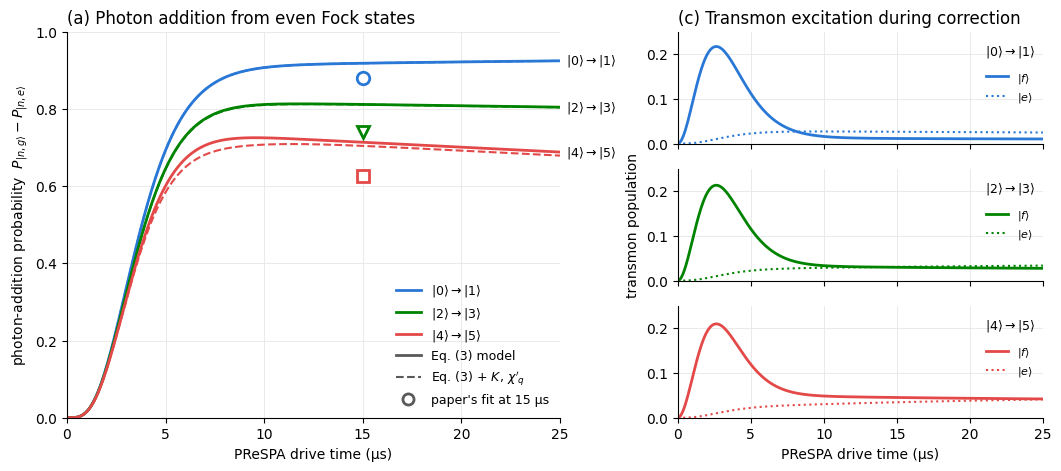

In [1]:
import os
import sys

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from AQEC import device as dev
from AQEC import master_equation as me
from AQEC.wigner import parity

TWO_PI = 2 * np.pi
os.makedirs("figures", exist_ok=True)

# Paper's fit after 15 us of drive (§8.4, App. A.6): (P_{n,g}, P_{n,e})
PAPER_15US = {0: (0.92, 0.04), 2: (0.78, 0.04), 4: (0.67, 0.045)}
STYLE = {0: dict(color="#2a78d6", marker="o", label=r"$|0\rangle \to |1\rangle$"),
         2: dict(color="#008300", marker="v", label=r"$|2\rangle \to |3\rangle$"),
         4: dict(color="#e34948", marker="s", label=r"$|4\rangle \to |5\rangle$")}


def tidy(ax, grid=True):
    """House style for every figure in §10: recessive grid, no top/right spines."""
    if grid:
        ax.grid(color="0.9", lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


sim = me.simulate_fig2()                                  # Eq. (3) as printed, frame (i)
sim_d1 = me.simulate_fig2(include_higher_order=True)      # + K, chi'_q (decision D1)

fig = plt.figure(figsize=(10.5, 4.6), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[1.35, 1.0])
ax_a = fig.add_subplot(gs[:, 0])
ax_c = [fig.add_subplot(gs[k, 1]) for k in range(3)]

for n0, st in STYLE.items():
    s, s1 = sim[n0], sim_d1[n0]
    ax_a.plot(s["t"], s["Png"] - s["Pne"], color=st["color"], lw=2, label=st["label"])
    ax_a.plot(s1["t"], s1["Png"] - s1["Pne"], color=st["color"], lw=1.5, ls="--")
    pg, pe = PAPER_15US[n0]
    ax_a.plot(15.0, pg - pe, ls="none", marker=st["marker"], ms=9, mfc="white",
              mec=st["color"], mew=2)
    ax_a.annotate(st["label"], (s["t"][-1], (s["Png"] - s["Pne"])[-1]),
                  xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax_a.plot([], [], color="0.35", lw=2, label="Eq. (3) model")
ax_a.plot([], [], color="0.35", lw=1.5, ls="--", label=r"Eq. (3) + $K$, $\chi'_q$")
ax_a.plot([], [], ls="none", marker="o", ms=8, mfc="white", mec="0.35", mew=2,
          label="paper's fit at 15 μs")
ax_a.set(xlim=(0, 25), ylim=(0, 1), xlabel="PReSPA drive time (μs)",
         ylabel=r"photon-addition probability  $P_{|n,g\rangle} - P_{|n,e\rangle}$")
ax_a.set_title("(a) Photon addition from even Fock states", loc="left")
ax_a.legend(loc="lower right", fontsize=9, frameon=False)

for ax, (n0, st) in zip(ax_c, STYLE.items()):
    s = sim[n0]
    ax.plot(s["t"], s["Pf"], color=st["color"], lw=2, label=r"$|f\rangle$")
    ax.plot(s["t"], s["Pe"], color=st["color"], lw=1.5, ls=":", label=r"$|e\rangle$")
    ax.set(xlim=(0, 25), ylim=(0, 0.25), yticks=[0, 0.1, 0.2])
    ax.text(0.98, 0.9, st["label"], transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.legend(loc="center right", fontsize=8, frameon=False)
    if ax is not ax_c[-1]:
        ax.tick_params(labelbottom=False)
ax_c[0].set_title("(c) Transmon excitation during correction", loc="left")
ax_c[1].set_ylabel("transmon population")
ax_c[-1].set_xlabel("PReSPA drive time (μs)")

for ax in [ax_a, *ax_c]:
    tidy(ax)
fig.savefig("figures/aqec_fig2ac.pdf")
fig.savefig("figures/aqec_fig2ac.png", dpi=200)
plt.show()

**Figure 1.** Photon addition from even Fock states; replicates PRX Fig. 2(a) and 2(c).

*Model.* The §8 master equation in frame (i): Eq. (3) at $\Omega_1/2\pi = 55$ kHz and $\Omega_2/2\pi = 160$ kHz, with
storage loss ($T_{1a} = 136$ μs), readout loss ($\kappa_r/2\pi = 0.58$ MHz) and the two transmon decays
($T_1^{ge} = 50$ μs, $T_1^{ef} = 31$ μs).

**(a)** The photon-addition signal $P_{|n,g\rangle} - P_{|n,e\rangle}$ at $n = n_0 + 1$, starting from $|n_0, g, 0\rangle$.
- Colours: $n_0 = 0$ blue, 2 green, 4 red.
- Solid lines: Eq. (3) as printed.
- Dashed lines: with the storage self-Kerr $K$ and the sixth-order shift $\chi'_q$ added (decision D1). They separate
  from the solid lines only for $n_0 = 4$.
- Open markers: the paper's master-equation fit at 15 μs (App. A.6). The paper's measured points are not
  reproduced.

**(c)** Total transmon $|f\rangle$ population (solid) and $|e\rangle$ population (dotted) for the same three initial
states. The $|f\rangle$ transient peaks at ≈ 0.21 near 2.6 μs on every path, as in the paper. The $|e\rangle$
population comes from $f \to e$ decays in the middle of a correction.

*Comparison.* The curves have the paper's shape and timescale, but at 15 μs they sit 0.04–0.09 above the paper's fit
([§10.2](#102-comparison-with-the-papers-fit-at-15-μs), [§10.6](#106-what-matches-and-what-does-not)).

## 10.2 Comparison with the paper's fit at 15 μs

Each cell `P_g / P_e` is the probability that the photon was added (to $n = n_0 + 1$) with the transmon
back in $|g\rangle$ (corrected, ground) or stuck in $|e\rangle$ (corrected, excited): $P_{|n,g\rangle}$ and $P_{|n,e\rangle}$.
The second block shows $P_g - P_e$ minus the paper's value.

The table below runs the same benchmark under several transmon-decay conventions:

- **Single $\mathcal D[\hat q]$:** the paper writes one transmon dissipator. Because
  $\langle e|\hat q|f\rangle = \sqrt2$, a single rate $\gamma$ makes the $f \to e$ decay run at $2\gamma$, so it cannot
  reproduce both measured lifetimes ([§8.1](#81-master-equation-and-jump-operators)).
- **No transmon decay:** shows how much of $P_{|n,e\rangle}$ the transmon decays account for.
- **Six tones (last row):** the full drive of [§10.4](#104-frame-ii-the-solver-for-coherences), in which every tone
  acts on every path, solved in frame (ii).

In [2]:
# 15 us benchmark against the paper's fit (§8.4), for several transmon-decay conventions
VARIANTS = [
    ("two ops, T1ge=50, T1ef=31 (§8.1)", dict(transmon_decay="split")),
    ("  + K, chi'_q (D1)",               dict(transmon_decay="split", include_higher_order=True)),
    ("single D[q], 1/T1ge (T1ef -> 25)",  dict(transmon_decay="single_q", gamma=1 / dev.T1_GE)),
    ("no transmon decay",                dict(transmon_decay="none")),
]
PATH = {0: "0->1", 2: "2->3", 4: "4->5"}


def at15(s, key):
    return s[key][np.argmin(np.abs(s["t"] - 15.0))]


def half_time(s):
    """Dissipation half-time: first time P_{n,g} - P_{n,e} reaches half its 15 us value."""
    sig = s["Png"] - s["Pne"]
    return s["t"][np.argmax(sig >= 0.5 * (at15(s, "Png") - at15(s, "Pne")))]


def row(name, cells):
    print(f"{name:36s}" + "".join(f"{c:>18s}" for c in cells))


runs = {name: me.simulate_fig2(t_max=15.0, **kw) for name, kw in VARIANTS}


def six_tone_fig2(t_final=15.0):
    """Fock-state runs of the six-tone drive (frame ii, + K, chi'_q), at t_final only."""
    out = {}
    for n0 in STYLE:
        psi = me.ket(n0, me.G, 0)
        rho = me.simulate_frame_ii(np.outer(psi, psi), [0.0, t_final], include_higher_order=True,
                                   six_tones=True)
        out[n0] = {"t": np.array([0.0, t_final]), **me.fig2_observables(rho, n0 + 1)}
    return out


runs["  + six tones (frame ii, §10.4)"] = six_tone_fig2()

row("P_g / P_e at 15 us", [PATH[n0] for n0 in STYLE])
row("paper fit (§8.4)", [f"{g:.3f} / {e:.3f}" for g, e in PAPER_15US.values()])
for name, s in runs.items():
    row(name, [f"{at15(s[n0], 'Png'):.3f} / {at15(s[n0], 'Pne'):.3f}" for n0 in STYLE])

print()
row("(P_g - P_e) minus paper", [PATH[n0] for n0 in STYLE])
for name, s in runs.items():
    row(name, [f"{at15(s[n0], 'Png') - at15(s[n0], 'Pne') - (g - e):+.3f}"
               for n0, (g, e) in PAPER_15US.items()])

print("\ndissipation half-time, default model (us): "
      + ",  ".join(f"{PATH[n0]}: {half_time(sim[n0]):.2f}" for n0 in STYLE) + "   (paper: tau_cor ~ 4)")

P_g / P_e at 15 us                                0->1              2->3              4->5
paper fit (§8.4)                         0.920 / 0.040     0.780 / 0.040     0.670 / 0.045
two ops, T1ge=50, T1ef=31 (§8.1)         0.941 / 0.023     0.832 / 0.020     0.732 / 0.018
  + K, chi'_q (D1)                       0.941 / 0.023     0.832 / 0.020     0.722 / 0.018
single D[q], 1/T1ge (T1ef -> 25)         0.935 / 0.028     0.827 / 0.025     0.726 / 0.022
no transmon decay                        0.965 / 0.000     0.856 / 0.000     0.755 / 0.000
  + six tones (frame ii, §10.4)          0.939 / 0.023     0.830 / 0.020     0.714 / 0.019

(P_g - P_e) minus paper                           0->1              2->3              4->5
two ops, T1ge=50, T1ef=31 (§8.1)                +0.038            +0.072            +0.088
  + K, chi'_q (D1)                              +0.038            +0.071            +0.079
single D[q], 1/T1ge (T1ef -> 25)                +0.027            +0.061            +0.07

## 10.3 Correction rate of one path: Fig. 2(b)

Fig. 2(b) needs no master equation. It maps one eigenvalue $\lambda$ of the 3 × 3 non-Hermitian matrix of Eq. (B2)
([§7.1](#71-a-33-model-of-one-correction-path-app-b)) over the drive rates.

- **Which eigenvalue.** App. B picks the eigenvalue whose eigenvector overlaps most with the error state
  $|n{-}1,g,0\rangle$. The figure caption says "the smallest imaginary component". Over the plotted range the two rules
  pick the same eigenvalue.
- **What is plotted.** The rate is $|\mathrm{Im}\,\lambda|/2\pi$. It equals 57.5 kHz at the operating point, as
  [Appendix B](#appendix-b-numerical-check-of-every-derived-number) also finds.

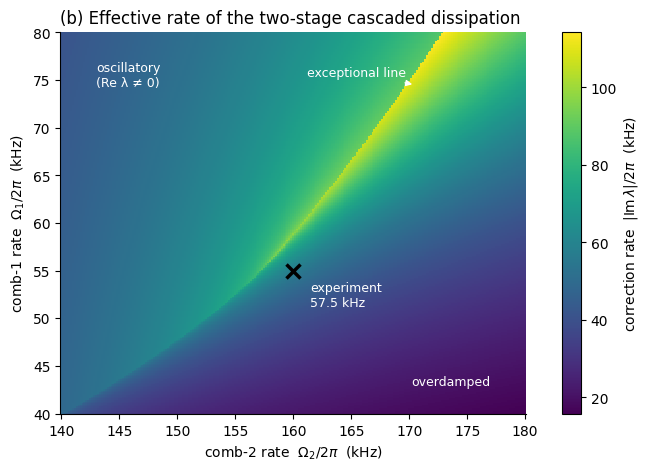

operating point: 57.5 kHz, Re lambda = 0.0 kHz (overdamped);  map range 15.6-114.4 kHz


In [3]:
# Fig. 2(b): correction rate of one path from the 3x3 model, Eq. (B2) -- no master equation
om2_kHz = np.linspace(140, 180, 241)
om1_kHz = np.linspace(40, 80, 241)
rate, osc = me.correction_rate_map(TWO_PI * 1e-3 * om1_kHz, TWO_PI * 1e-3 * om2_kHz)
rate_kHz = 1e3 * rate / TWO_PI
op_rate = 1e3 * me.b2_correction_rate(dev.OMEGA_1, dev.OMEGA_2)[0] / TWO_PI

fig, ax = plt.subplots(figsize=(6.4, 4.6), constrained_layout=True)
mesh = ax.pcolormesh(om2_kHz, om1_kHz, rate_kHz, cmap="viridis", shading="auto")
cb = fig.colorbar(mesh, ax=ax)
cb.set_label(r"correction rate  $|\mathrm{Im}\,\lambda|/2\pi$  (kHz)")
ax.plot(1e3 * dev.OMEGA_2 / TWO_PI, 1e3 * dev.OMEGA_1 / TWO_PI, marker="x", ms=10, mew=2.5,
        color="black", ls="none")
ax.annotate(f"experiment\n{op_rate:.1f} kHz", (160, 55), xytext=(12, -26),
            textcoords="offset points", fontsize=9, color="white")
ax.text(143, 77, "oscillatory\n(Re λ ≠ 0)", color="white", fontsize=9, va="top")
ax.annotate("exceptional line", (170.5, 74.5), xytext=(-78, 6), textcoords="offset points",
            color="white", fontsize=9, arrowprops=dict(arrowstyle="-|>", color="white", lw=1))
ax.text(177, 43, "overdamped", color="white", fontsize=9, ha="right")
ax.set(xlabel=r"comb-2 rate  $\Omega_2/2\pi$  (kHz)", ylabel=r"comb-1 rate  $\Omega_1/2\pi$  (kHz)")
ax.set_title("(b) Effective rate of the two-stage cascaded dissipation", loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.savefig("figures/aqec_fig2b.pdf")
fig.savefig("figures/aqec_fig2b.png", dpi=200)
plt.show()
osc_at_op = me.b2_correction_rate(dev.OMEGA_1, dev.OMEGA_2)[1]
print(f"operating point: {op_rate:.1f} kHz, Re lambda = {1e3 * osc_at_op / TWO_PI:.1f} kHz (overdamped);"
      f"  map range {rate_kHz.min():.1f}-{rate_kHz.max():.1f} kHz")

**Figure 2.** Effective correction rate of one path against the two drive rates; replicates PRX Fig. 2(b).

*Colour.* $|\mathrm{Im}\,\lambda|/2\pi$, where $\lambda$ is the eigenvalue of the Eq. (B2) matrix
($\kappa_r/2\pi = 0.58$ MHz) whose eigenvector overlaps most with the error state $|n{-}1,g,0\rangle$.

*Ridge.* The bright ridge is the exceptional line, where this eigenvalue merges with another. Above and to the left
of it the relaxation oscillates ($\mathrm{Re}\,\lambda \neq 0$); below and to the right it is overdamped. The fastest
non-oscillating correction therefore lies just on the overdamped side of the line.

*×.* The experiment: $\Omega_1/2\pi = 55$ kHz, $\Omega_2/2\pi = 160$ kHz, rate 57.5 kHz. It sits just inside the
overdamped region; at this $\Omega_2$ the eigenvalue splits at $\Omega_1/2\pi \approx 58.9$ kHz (Appendix B).

*Comparison.* Same quantity, axes and operating point as the paper. The paper's colour bar is labelled up to 90 kHz;
ours runs to 114 kHz at the top of the ridge.

## 10.4 Frame (ii): the solver for coherences

**What is integrated.** `simulate_frame_ii` integrates $\hat H^{\rm (ii)}(t)$ of [§8.2](#82-rotating-frame).
The dispersive terms stay explicit, and each tone carries its phase $e^{\pm in\chi_{gf}t}$. The density-matrix ODE is
solved with `scipy`'s DOP853 integrator ($r_{\rm tol} = 10^{-9}$). The Hamiltonian repeats every
$2\pi/\chi_{gf} \approx 0.48$ μs, and a 15 μs run takes about a second.

**The six-tone switch.** It replaces Eq. (3) with all six tones acting on every transition of their process:

- comb-1 tone $n$ adds $(\Omega_1/\sqrt n)\,e^{in\chi_{gf}t}\,\hat a^\dagger|f\rangle\langle g| + \text{h.c.}$;
- comb-2 tone $n$ adds $\Omega_2\,e^{-in\chi_{gf}t}\,|g\rangle\langle f|\,\hat r^\dagger + \text{h.c.}$

Eq. (3) is exactly the resonant part of these. The rest is what [§7.3](#73-parity-selectivity-unwanted-corrections-app-e2)
calls unwanted corrections, plus small cross-path Stark shifts.

**Check: how far frame (i) is from exact for populations.** [§8.2](#82-rotating-frame) estimates that frame (i)
changes no population by more than 0.003. The cell below measures it.

- *Mechanism.* A photon lost during path 5's $g \leftrightarrow f$ oscillation carries the
  $|4,g,0\rangle\langle 5,f,0|$ coherence down one rung. A second loss lands it on path 3's driven pair
  $|2,g,0\rangle\langle 3,f,0|$, where it interferes with path 3's own oscillation.
- *Frame (i)* uses a time-independent $\mathcal D[\hat a]$, so the transferred coherence keeps a fixed phase.
- *The lab, reproduced by frame (ii):* that phase rotates at multiples of $\chi$ and averages out.
- *Size:* up to $2.6 \times 10^{-3}$ on $|3,g,0\rangle$ from $|4,g,0\rangle$, and zero from $|0,g,0\rangle$, which
  confirms §8.2's estimate. The quantities plotted in Figure 1 move by at most $4 \times 10^{-4}$, so Figure 1
  stands in frame (i).

In [4]:
# Frame (ii) against frame (i) and against qutip; six-tone drive on a code state
t = np.arange(0.0, 25.0 + 1e-9, 0.25)
L_i = me.liouvillian(me.drive_hamiltonian(), me.collapse_operators())
worst_obs, worst_pop = 0.0, 0.0
for n0 in STYLE:
    psi = me.ket(n0, me.G, 0)
    r_i = me.propagate(L_i, np.outer(psi, psi), t)
    r_ii = me.simulate_frame_ii(np.outer(psi, psi), t)
    o_i, o_ii = me.fig2_observables(r_i, n0 + 1), me.fig2_observables(r_ii, n0 + 1)
    worst_obs = max(worst_obs, max(np.max(np.abs(o_i[k] - o_ii[k])) for k in o_i))
    worst_pop = max(worst_pop, np.max(np.abs(np.einsum("tii->ti", r_i - r_ii))))
print(f"frame (ii) vs frame (i), Fock starts, 0-25 us:")
print(f"    max |difference| in any Fock/transmon population = {worst_pop:.1e}  (double-loss channel, see text)")
print(f"    max |difference| in the Fig. 2(a)/(c) quantities = {worst_obs:.1e}")

try:
    import qutip
    from validation.test_aqec_master_equation import qutip_fig2, qutip_frame_ii
except ImportError:
    print("qutip not installed; skipping the qutip cross-checks (pip install qutip)")
else:
    ref = qutip_fig2(sim_d1[0]["t"], include_higher_order=True)
    d_i = max(np.max(np.abs(sim_d1[n0][k] - ref[n0][k])) for n0 in STYLE for k in ("Png", "Pne", "Pe", "Pf"))
    psi = (me.ket(2, me.G, 0) + me.ket(4, me.G, 0)) / np.sqrt(2)
    rho0 = np.outer(psi, psi)
    d_ii = np.max(np.abs(me.simulate_frame_ii(rho0, [0.0, 2.0], include_higher_order=True)[-1]
                         - qutip_frame_ii(rho0, [0.0, 2.0])[-1]))
    print(f"qutip {qutip.__version__}: frame (i), all Fig. 2 curves, 0-25 us:  max |numpy - mesolve| = {d_i:.1e}")
    print(f"           frame (ii), full rho from (|2>+|4>)/sqrt2, 0-2 us: max |numpy - mesolve| = {d_ii:.1e}")

# Unwanted corrections (App. E.2): the six-tone drive also acts on the odd code state |3>
psi = me.ket(3, me.G, 0)
P3 = {six: me.storage_reduced(me.simulate_frame_ii(np.outer(psi, psi), [0.0, 15.0], True, six)[-1])[3, 3].real
      for six in (False, True)}
gamma = -np.log(P3[True] / P3[False]) / 15.0
print(f"\ncode state |3,g,0> after 15 us:  P_3 = {P3[False]:.4f} (Eq. 3),  {P3[True]:.4f} (six tones)")
print(f"    extra loss rate from the off-resonant tones = {1e3 * gamma:.2f} ms^-1"
      f"   (paper, Table III unwanted corrections: 0.4 ms^-1)")

frame (ii) vs frame (i), Fock starts, 0-25 us:
    max |difference| in any Fock/transmon population = 2.6e-03  (double-loss channel, see text)
    max |difference| in the Fig. 2(a)/(c) quantities = 4.1e-04
qutip 5.0.4: frame (i), all Fig. 2 curves, 0-25 us:  max |numpy - mesolve| = 5.5e-11
           frame (ii), full rho from (|2>+|4>)/sqrt2, 0-2 us: max |numpy - mesolve| = 3.8e-07

code state |3,g,0> after 15 us:  P_3 = 0.9243 (Eq. 3),  0.9166 (six tones)
    extra loss rate from the off-resonant tones = 0.56 ms^-1   (paper, Table III unwanted corrections: 0.4 ms^-1)


## 10.5 Coherence through photon addition: Fig. 2(d)

**Runs.** Each run starts in $\tfrac{1}{\sqrt2}(|m\rangle + |n\rangle) \otimes |g,0\rangle$ for
$(m, n) = (0,2), (0,4), (2,4)$ and drives for 15 μs in frame (ii), with $K$ and $\chi'_q$ included. The paper
attributes the rotation of its final states to $K$.

**Storage state.** The storage state is $\hat\rho_a = \mathrm{Tr}_{q,r}\,\hat\rho$.

**Coherence factor.** The paper's "coherence preservation factor" is the ratio of the off-diagonal elements:

$$
\frac{|\rho_{m+1,n+1}(15\ \mu\text{s})|}{|\rho_{mn}(0)|}.
$$

**Frame comparison.** The table also runs frame (i), which overstates coherence because it hides the phase that a
mid-correction transmon decay leaves on each photon number (§8.2), and the six-tone drive.

In [5]:
# Fig. 2(d) numbers: coherence preservation factor |rho_{m+1,n+1}(15 us)| / |rho_{mn}(0)|
PAPER_COH = {(0, 2): 0.84, (0, 4): 0.75, (2, 4): 0.62}
fig2d = {
    "frame (i)":              me.simulate_fig2d(frame="i"),
    "frame (ii)":             me.simulate_fig2d(),                 # used for Figure 3
    "frame (ii), six tones":  me.simulate_fig2d(six_tones=True),
}
pairs = list(PAPER_COH)
label = lambda p: f"|{p[0]}>+|{p[1]}>"
print(f"{'coherence factor (all + K, chi_q)':34s}" + "".join(f"{label(p):>16s}" for p in pairs))
print(f"{'paper (Fig. 2d)':34s}" + "".join(f"{PAPER_COH[p]:>16.2f}" for p in pairs))
for name, res in fig2d.items():
    print(f"{name:34s}" + "".join(f"{res[p]['coherence']:>16.3f}" for p in pairs))
print(f"\n{'phase of rho_(m+1,n+1), frame (ii)':34s}" +
      "".join(f"{fig2d['frame (ii)'][p]['phase']:>+13.2f} rad" for p in pairs))
print(f"{'populations m+1 / n+1, frame (ii)':34s}" +
      "".join(f"{res_p['rho'][p[0] + 1, p[0] + 1].real:>9.3f} /{res_p['rho'][p[1] + 1, p[1] + 1].real:.3f}"
              for p, res_p in fig2d["frame (ii)"].items()))

coherence factor (all + K, chi_q)          |0>+|2>         |0>+|4>         |2>+|4>
paper (Fig. 2d)                               0.84            0.75            0.62
frame (i)                                    0.900           0.796           0.793
frame (ii)                                   0.874           0.784           0.775
frame (ii), six tones                        0.868           0.776           0.770

phase of rho_(m+1,n+1), frame (ii)        -0.73 rad        -2.61 rad        -1.86 rad
populations m+1 / n+1, frame (ii)     0.512 /0.434    0.486 /0.381    0.490 /0.381


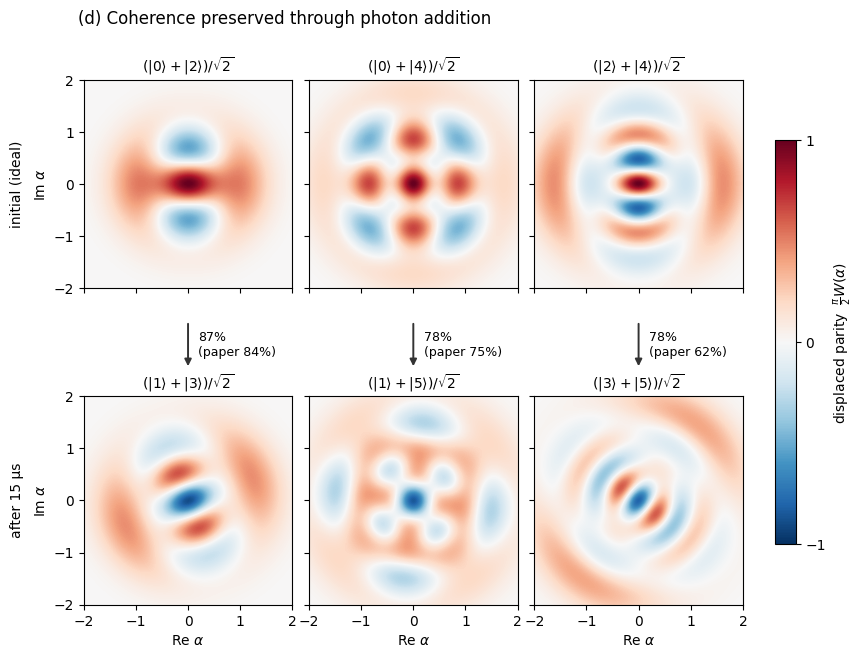

In [6]:
# Fig. 2(d): Wigner functions before (ideal) and after 15 us of PReSPA (frame ii, + K, chi'_q)
xv = np.linspace(-2.0, 2.0, 201)
ket_tex = lambda m, n: rf"$(|{m}\rangle + |{n}\rangle)/\sqrt{{2}}$"
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.0), sharex=True, sharey=True,
                         gridspec_kw=dict(hspace=0.42, wspace=0.08))
for k, (m, n) in enumerate(pairs):
    res = fig2d["frame (ii)"][(m, n)]
    for row_i, (rho, title) in enumerate([(res["rho0"], ket_tex(m, n)),
                                          (res["rho"], ket_tex(m + 1, n + 1))]):
        ax = axes[row_i, k]
        im = ax.imshow(parity(rho, xv, xv), extent=(-2, 2, -2, 2), origin="lower",
                       cmap="RdBu_r", vmin=-1, vmax=1, interpolation="bilinear")
        ax.set_title(title, fontsize=10)
        ax.set_xticks([-2, -1, 0, 1, 2])
        ax.set_yticks([-2, -1, 0, 1, 2])
    axes[1, k].annotate("", xy=(0.5, 1.13), xytext=(0.5, 1.36), xycoords="axes fraction",
                        arrowprops=dict(arrowstyle="-|>", color="0.2", lw=1.4))
    axes[1, k].text(0.55, 1.245, f"{100 * res['coherence']:.0f}%\n(paper {100 * PAPER_COH[(m, n)]:.0f}%)",
                    transform=axes[1, k].transAxes, fontsize=9, va="center")
for ax in axes[1]:
    ax.set_xlabel(r"Re $\alpha$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Im $\alpha$")
axes[0, 0].text(-0.32, 0.5, "initial (ideal)", transform=axes[0, 0].transAxes, rotation=90,
                va="center", ha="center", fontsize=10)
axes[1, 0].text(-0.32, 0.5, "after 15 μs", transform=axes[1, 0].transAxes, rotation=90,
                va="center", ha="center", fontsize=10)
cb = fig.colorbar(im, ax=axes, shrink=0.75, pad=0.04, ticks=[-1, 0, 1])
cb.set_label(r"displaced parity  $\frac{\pi}{2}W(\alpha)$")
fig.suptitle("(d) Coherence preserved through photon addition", x=0.12, ha="left", y=0.97)
fig.savefig("figures/aqec_fig2d.pdf", bbox_inches="tight")
fig.savefig("figures/aqec_fig2d.png", dpi=200, bbox_inches="tight")
plt.show()

**Figure 3.** Coherence preserved through photon addition; replicates PRX Fig. 2(d).

*What is shown.* Wigner functions of the storage, displayed as the displaced parity $\tfrac{\pi}{2}W(\alpha)$ (the
paper's colour scale), before (top) and after (bottom) 15 μs of PReSPA. The runs start from
$\tfrac{1}{\sqrt2}(|m\rangle + |n\rangle) \otimes |g,0\rangle$.

- **Top row:** the ideal initial states. The paper's top row is measured after optimal-control state preparation.
- **Bottom row:** the frame-(ii) master equation of §10.4 with $K$ and $\chi'_q$, after tracing out the transmon and
  readout. Each panel is titled with the odd-parity state it approximates.
- **Arrows:** the coherence-preservation factor $|\rho_{m+1,n+1}(15\ \mu\text{s})|/|\rho_{mn}(0)|$, with the
  paper's value in parentheses.

*Rotation.* The tilt of the bottom row is the self-Kerr phase, $\arg\rho_{m+1,n+1} = -0.73$, $-2.61$ and
$-1.86$ rad. The paper's orientation also depends on its tomography frame, so only the presence of a rotation can be
compared, not its angle.

*Rendering.* The paper's panels are pixelated because of its measurement grid; these are rendered smooth.

## 10.6 What matches and what does not

**What matches.**

- **Fig. 2(a), (c):**
  - the dissipation half-time is 3.3–3.6 μs, against the paper's $\tau_{\rm cor} \approx 4$ μs;
  - the plateaus are ordered $n = 1 > 3 > 5$;
  - $P_f$ peaks at ≈ 0.21 near 2.6 μs on every path.
- **Fig. 2(b):** the same quantity, the same ridge along the exceptional line, and the operating point just on its
  overdamped side.
- **Fig. 2(d):**
  - the initial-state patterns;
  - the decrease of coherence from $(0,2)$ to $(0,4)$ (87% → 78%, against 84% → 75%);
  - a deterministic Kerr rotation.
- **Unwanted corrections:** the six-tone drive reproduces them. The code state $|3\rangle$ loses an extra
  0.56 ms⁻¹, against the paper's 0.4 ms⁻¹ (Table III).

**What does not match.**

- **Populations.** At 15 μs the default model sits above the paper's fit by +0.04, +0.07 and +0.09 for
  $n = 1, 3, 5$. Its $P_{|n,e\rangle} \approx 0.02$ is half the paper's 0.04.
  - With the paper's single $\mathcal D[\hat q]$ at $\gamma = 1/T_1^{ef}$, $n = 1$ matches. That convention, however,
    puts $f \to e$ at 15.5 μs, half the measured $T_1^{ef}$, so the match is not evidence for it.
  - Under every convention, an overshoot that grows with $n$ remains.
- **Coherence factors.** Frame (ii) gives 0.87, 0.78 and 0.78, against the paper's 0.84, 0.75 and 0.62.
  - The first two are 0.03 high, in line with the population overshoot.
  - $(2,4)$ is 0.16 high. In our model $(|1\rangle+|5\rangle)$ and $(|3\rangle+|5\rangle)$ keep nearly equal
    coherence (0.784 against 0.775). In the paper the second is 0.13 lower.

**Candidate causes, updated.**

1. **Off-resonant tones.** *Tested and ruled out.* The six-tone drive moves every population and coherence factor by
   at most 0.009 (§10.2, §10.5).
2. **Calibration on $n = 1$ only** ([§5.4](#54-how-the-tones-are-generated-and-calibrated-app-a4)). Untested. A static
   residual detuning on paths 3 and 5 slows them. Drift in that detuning from shot to shot would also dephase
   $|3\rangle$ against $|5\rangle$, which is the pattern the $(2,4)$ coherence suggests.
3. **Extra parameters in the paper's fit.** Untested. The paper names its fit model only as
   "$\hat H_d$ with $\mathcal D[\hat r]$, $\mathcal D[\hat a]$, $\mathcal D[\hat q]$". A fitted $\kappa_a$, or a
   state-preparation scale factor absorbed into the $|2\rangle$ and $|4\rangle$ curves, would give an $n$-dependent
   offset.
4. **Transmon heating and dephasing (D3).** Untested. Neither is in the model; Table III books heating at
   0.7 ms⁻¹.

# Appendix A. Experimental setup (App. A.1-A.2, Fig. 7)

Context only; none of this is needed to check the Hamiltonian.

- **Package.** A 3D-planar hybrid design machined from 99.9995% aluminum and chemically etched. The storage is the
  λ/4 mode of a vertical cylindrical waveguide with a centre post. A sapphire chip in a horizontal tunnel holds the
  transmon (an Al/AlOₓ/Al Dolan-bridge junction) and the λ/2 stripline readout resonator. $\chi_{ge}$ is tuned by the
  amount of indium in the chip clamp.
- **Storage lifetime.** $T_{1a} = 136$ μs is low for this type of cavity (typically about 1 ms). The paper attributes it
  to a degraded surface: after all data were taken, a 20 s etch (about 50 nm) restored $T_{1a} = 1.1$ ms.
- **Readout.** A HEMT amplifier at 4 K and a room-temperature amplifier, with no parametric amplifier. Readout fidelity
  is 88%, which is enough here because the scheme never measures during correction.
- **Filtering.** Eccosorb filters, a 30 dB attenuator on the mixing chamber and Eccosorb foam inside the magnetic
  shield reduced transmon relaxation and spurious excitation.

**Microwave channels.** Five IQ-modulated channels; the transmon, readout and both FWM combs are combined with power
dividers into the single transmon input port.

| channel | port | used for |
|---|---|---|
| storage | dedicated storage port | state preparation and decoding (optimal-control pulses) |
| transmon | transmon input | photon-number-selective π pulses, tomography |
| readout | transmon input | dispersive readout |
| FWM1 | transmon input | comb 1 (stage 1) |
| FWM2 | transmon input | comb 2 (stage 2) |

# Appendix B. Numerical check of every derived number

Recomputes the numbers quoted above from `AQEC/device.py` and `AQEC/odd_kitten.py`. Pure numpy; it runs in about a
second. Start Jupyter from the repository root.

In [7]:
import os
import sys

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
from AQEC import device as dev
from AQEC import odd_kitten

TWO_PI = 2 * np.pi
PATHS = dev.CORRECTED_FOCK                                        # (1, 3, 5)
QUIET = dict(divide="ignore", over="ignore", invalid="ignore")    # Accelerate BLAS, see odd_kitten.py


def to_MHz(w):
    return w / TWO_PI


def to_kHz(w):
    return np.round(1e3 * w / TWO_PI, 6) + 0.0     # + 0.0 turns -0.0 into 0.0


# §2  derived parameters
print("§2  derived parameters")
print(f"    chi_gf/2pi   = {to_MHz(dev.chi_gf):.2f} MHz")
print(f"    omega_gf/2pi = {to_MHz(dev.omega_gf):.2f} MHz")
print(f"    kappa_a/2pi  = {to_kHz(dev.kappa_a):.2f} kHz,  T1a/nbar = {dev.T1_CAVITY / 3:.1f} us")

# §5  tones and sum rule
w1 = {n: dev.omega_a + dev.omega_gf - n * dev.chi_gf for n in PATHS}
w2 = {n: dev.omega_r - dev.omega_gf + n * dev.chi_gf for n in PATHS}
print("\n§5  tones (MHz)       comb 1      comb 2         sum   comb-1 amplitude")
print(f"    centre      {to_MHz(dev.omega_a + dev.omega_gf):10.2f}  {to_MHz(dev.omega_r - dev.omega_gf):10.2f}")
for n in PATHS:
    print(f"    n = {n}       {to_MHz(w1[n]):10.2f}  {to_MHz(w2[n]):10.2f}  {to_MHz(w1[n] + w2[n]):10.2f}"
          f"   1/sqrt({n}) = {1 / np.sqrt(n):.3f}")
print(f"    tone spacing 2 chi_gf/2pi = {to_MHz(2 * dev.chi_gf):.2f} MHz")
assert all(np.isclose(w1[n] + w2[n], dev.omega_a + dev.omega_r) for n in PATHS), "sum rule violated"

# §3.2  path-dependent shifts from K and chi'_q (our estimate, paper's signs)
print("\n§3.2 resonance shifts (kHz)   -K(n-1)   +chi'_q n(n-1)   stage 1   stage 2   sum")
for n in PATHS:
    dK, dX = -dev.K_a * (n - 1), dev.chi_q_p * n * (n - 1)
    print(f"    n = {n}                   {to_kHz(dK):8.1f}   {to_kHz(dX):14.1f}"
          f"   {to_kHz(dK + dX):7.1f}   {to_kHz(-dX):7.1f}   {to_kHz(dK):5.1f}")

# §4  code: Knill-Laflamme (asserted inside logical_basis) and the PReSPA image of |0_E>
n_c = odd_kitten.MIN_N_C
B = odd_kitten.logical_basis(n_c)          # raises AssertionError if Knill-Laflamme fails
E = odd_kitten.error_basis(n_c)
Pi_cor = np.zeros((n_c, n_c))
for k in range(0, n_c - 1, 2):
    Pi_cor[k + 1, k] = 1.0                 # sum_n |2n+1><2n|
with np.errstate(**QUIET):
    img = Pi_cor @ E[:, 0]
img = img / np.linalg.norm(img)
print("\n§4  Knill-Laflamme conditions: pass")
print(f"    Pi_cor|0_E> on |1>, |5>: {img[1].real:.4f}, {img[5].real:.4f}"
      f"   (1/sqrt6 = {1 / np.sqrt(6):.4f}, sqrt(5/6) = {np.sqrt(5 / 6):.4f})")
print(f"    |<0_L| Pi_cor 0_E>|^2 = {abs(np.vdot(B[:, 0], img)) ** 2:.4f}   (not 1: the recovery is approximate)")


# §7.2  the 3x3 non-Hermitian model, Eq. (B2)
def correction_eigenvalue(om1, om2, kappa_r=dev.kappa_r):
    """Eigenvalue whose eigenvector overlaps most with |n-1, g, 0>."""
    H = np.array([[0, om1, 0], [om1, 0, om2], [0, om2, -0.5j * kappa_r]])
    w, v = np.linalg.eig(H)
    return w[np.argmax(np.abs(v[0]) ** 2)]


def split_point(om2):
    """Smallest Omega_1 at which that eigenvalue gains a real part (0.01 kHz grid)."""
    for om1 in TWO_PI * 1e-3 * np.arange(20.0, 80.0, 0.01):
        if abs(correction_eigenvalue(om1, om2).real) > TWO_PI * 1e-6:
            return om1


print("\n§7.2 eigenvalue of Eq. (B2), divided by 2 pi (kHz)")
for om1, om2, label in [(dev.kappa_r / 13, dev.kappa_r / 4, "kappa_r/13, kappa_r/4"),
                        (dev.OMEGA_1, dev.OMEGA_2, "experiment")]:
    lam = correction_eigenvalue(om1, om2)
    print(f"    {label:22s} Om1 = {to_kHz(om1):5.1f}, Om2 = {to_kHz(om2):5.1f}:"
          f"  Re = {to_kHz(lam.real):6.1f}, Im = {to_kHz(lam.imag):6.1f}")
for om2 in (dev.kappa_r / 4, dev.OMEGA_2):
    print(f"    at Om2 = {to_kHz(om2):5.1f} kHz the eigenvalue splits above Om1 = {to_kHz(split_point(om2)):.1f} kHz")

# §6.3  rates from Stark shifts, Eq. (C9), n = 1 tones
print("\n§6.3 from the Stark shifts of the n = 1 tones:")
print(f"    Omega_1/2pi = {to_kHz(np.sqrt(dev.chi_ge * dev.STARK_1)):.0f} kHz,"
      f"  Omega_2/2pi = {to_kHz(np.sqrt(dev.chi_qr * dev.STARK_2)):.0f} kHz")
print(f"    beta_1 = {np.sqrt(dev.STARK_1 / (2 * dev.alpha_q)):.4f},"
      f"  beta_2 = {np.sqrt(dev.STARK_2 / (2 * dev.alpha_q)):.4f}")

§2  derived parameters
    chi_gf/2pi   = 2.07 MHz
    omega_gf/2pi = 6831.52 MHz
    kappa_a/2pi  = 1.17 kHz,  T1a/nbar = 45.3 us

§5  tones (MHz)       comb 1      comb 2         sum   comb-1 amplitude
    centre        11489.42     1893.48
    n = 1         11487.35     1895.55    13382.90   1/sqrt(1) = 1.000
    n = 3         11483.21     1899.69    13382.90   1/sqrt(3) = 0.577
    n = 5         11479.07     1903.83    13382.90   1/sqrt(5) = 0.447
    tone spacing 2 chi_gf/2pi = 4.14 MHz

§3.2 resonance shifts (kHz)   -K(n-1)   +chi'_q n(n-1)   stage 1   stage 2   sum
    n = 1                        0.0              0.0       0.0       0.0     0.0
    n = 3                       -6.6             11.4       4.8     -11.4    -6.6
    n = 5                      -13.2             38.0      24.8     -38.0   -13.2

§4  Knill-Laflamme conditions: pass
    Pi_cor|0_E> on |1>, |5>: 0.4082, 0.9129   (1/sqrt6 = 0.4082, sqrt(5/6) = 0.9129)
    |<0_L| Pi_cor 0_E>|^2 = 0.8727   (not 1: the reco